# ECG Heartbeat Classification Project
## Phase 3 (EDA and Feature Extraction)
Performing exploratory data analysis on the segmented
heartbeat dataset and extracting meaningful features from each beat
for use in machine learning classification in Phase 4.

### Import libraries and load saved dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

# loading the dataset
data_path = '../data'

X = np.load(os.path.join(data_path, 'X_beats.npy'))
y = np.load(os.path.join(data_path, 'y_labels.npy'))
y_binary = np.load(os.path.join(data_path, 'y_binary.npy'))

print("Dataset loaded successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_binary shape: {y_binary.shape}")
print(f"\nClass distribution:")
for label, count in Counter(y).most_common():
    print(f"  {label}: {count} ({count/len(y)*100:.1f}%)")

Dataset loaded successfully!
X shape: (102382, 360)
y shape: (102382,)
y_binary shape: (102382,)

Class distribution:
  N: 75011 (73.3%)
  L: 8071 (7.9%)
  R: 7255 (7.1%)
  V: 7129 (7.0%)
  A: 2546 (2.5%)
  f: 982 (1.0%)
  F: 802 (0.8%)
  j: 229 (0.2%)
  a: 150 (0.1%)
  E: 106 (0.1%)
  J: 83 (0.1%)
  e: 16 (0.0%)
  S: 2 (0.0%)


### Visualise average beat shape per class

#### Normal beat baseline reference

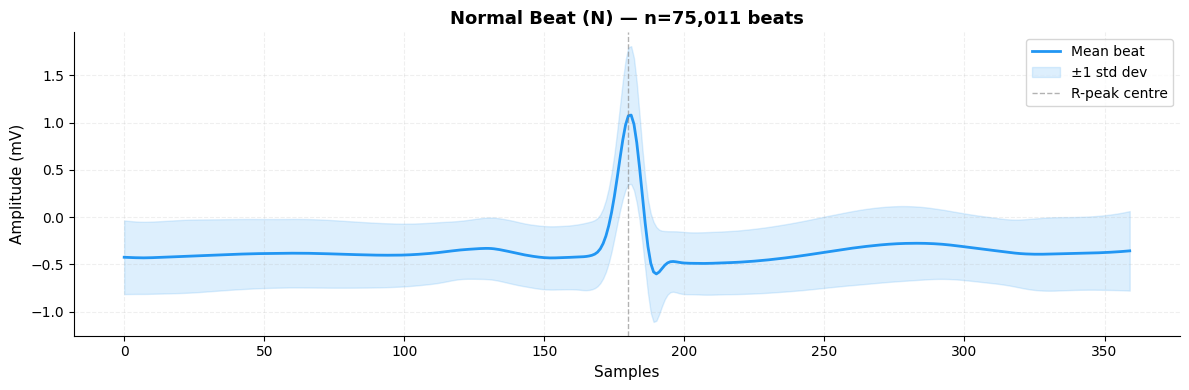

Normal beats: 75,011 out of 102,382 total (73.3%)
Mean R-peak amplitude: 1.073 mV
Mean std deviation: 0.370 mV


In [6]:
indices_n = np.where(y == 'N')[0]
mean_n = np.mean(X[indices_n], axis=0)
std_n = np.std(X[indices_n], axis=0)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(mean_n, color='#2196F3', linewidth=2, label='Mean beat')
ax.fill_between(range(360),
                mean_n - std_n,
                mean_n + std_n,
                alpha=0.15, color='#2196F3', label='±1 std dev')
ax.axvline(x=180, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='R-peak centre')

ax.set_title(f'Normal Beat (N) — n={len(indices_n):,} beats', fontsize=13, fontweight='bold')
ax.set_xlabel('Samples', fontsize=11)
ax.set_ylabel('Amplitude (mV)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Normal beats: {len(indices_n):,} out of {len(y):,} total ({len(indices_n)/len(y)*100:.1f}%)")
print(f"Mean R-peak amplitude: {mean_n[180]:.3f} mV")
print(f"Mean std deviation: {np.mean(std_n):.3f} mV")

#### Bundle branch block beats (Left and Right)
These beats occur when the electrical signal takes the wrong path
through the left or right side of the heart.

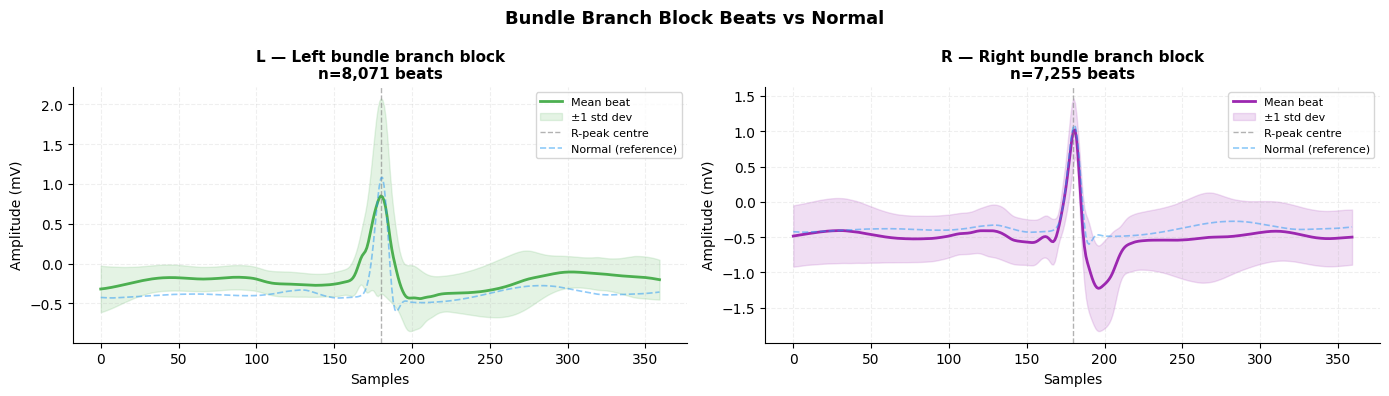

Left bundle branch block (L): 8,071 beats (7.9%)
Right bundle branch block (R): 7,255 beats (7.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bundle_types = [('L', '#4CAF50', 'Left bundle branch block'),
                ('R', '#9C27B0', 'Right bundle branch block')]

for ax, (beat_type, color, name) in zip(axes, bundle_types):
    indices = np.where(y == beat_type)[0]
    mean_beat = np.mean(X[indices], axis=0)
    std_beat = np.std(X[indices], axis=0)

    ax.plot(mean_beat, color=color, linewidth=2, label='Mean beat')
    ax.fill_between(range(360),
                    mean_beat - std_beat,
                    mean_beat + std_beat,
                    alpha=0.15, color=color, label='±1 std dev')
    ax.axvline(x=180, color='gray', linestyle='--',
               alpha=0.6, linewidth=1, label='R-peak centre')

    # Also overlay Normal beat for comparison
    ax.plot(mean_n, color='#2196F3', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Normal (reference)')

    ax.set_title(f'{beat_type} — {name}\nn={len(indices):,} beats',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Samples', fontsize=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bundle Branch Block Beats vs Normal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for beat_type, _, name in bundle_types:
    indices = np.where(y == beat_type)[0]
    print(f"{name} ({beat_type}): {len(indices):,} beats ({len(indices)/len(y)*100:.1f}%)")

#### Premature beats (Ventricular and Atrial)
These beats occur when the heart fires too early before the normal
electrical signal arrives.

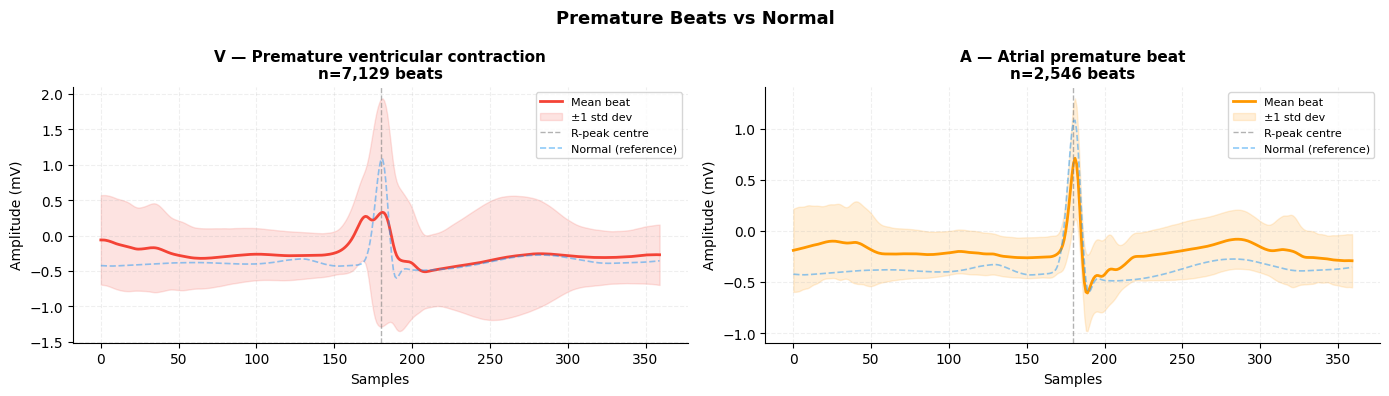

Premature ventricular contraction (V): 7,129 beats (7.0%)
Atrial premature beat (A): 2,546 beats (2.5%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

premature_types = [('V', '#F44336', 'Premature ventricular contraction'),
                   ('A', '#FF9800', 'Atrial premature beat')]

for ax, (beat_type, color, name) in zip(axes, premature_types):
    indices = np.where(y == beat_type)[0]
    mean_beat = np.mean(X[indices], axis=0)
    std_beat = np.std(X[indices], axis=0)

    ax.plot(mean_beat, color=color, linewidth=2, label='Mean beat')
    ax.fill_between(range(360),
                    mean_beat - std_beat,
                    mean_beat + std_beat,
                    alpha=0.15, color=color, label='±1 std dev')
    ax.axvline(x=180, color='gray', linestyle='--',
               alpha=0.6, linewidth=1, label='R-peak centre')

    # Overlay Normal beat for comparison
    ax.plot(mean_n, color='#2196F3', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Normal (reference)')

    ax.set_title(f'{beat_type} — {name}\nn={len(indices):,} beats',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Samples', fontsize=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Premature Beats vs Normal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for beat_type, _, name in premature_types:
    indices = np.where(y == beat_type)[0]
    print(f"{name} ({beat_type}): {len(indices):,} beats ({len(indices)/len(y)*100:.1f}%)")

### Observations from average beat shapes

The average beat shape plots reveal clear visual differences between
beat types across all 48 records:

- **Normal (N):** Sharp consistent R-peak at sample 180 with narrow
  standard deviation band, indicating high consistency across patients.

- **Left Bundle Branch Block (L):** Similar peak position to Normal
  but with distinctly different morphology around the QRS complex,
  reflecting the abnormal electrical conduction pathway.

- **Right Bundle Branch Block (R):** Notably inverted peak compared
  to Normal — the R-peak goes negative — due to reversed electrical
  signal direction through the right ventricle.

- **PVC (V):** Very wide standard deviation band indicating high
  variability across patients. The mean shape is almost flat,
  showing how differently PVC beats manifest between individuals.

- **Atrial Premature (A):** Visually most similar to Normal, confirming
  that A beats will be the most challenging class for the ML model
  to distinguish correctly in Phase 4.

### Class distribution(Frequency Distribution Chart)
Visualising the frequency of each beat type across all 48 patients.


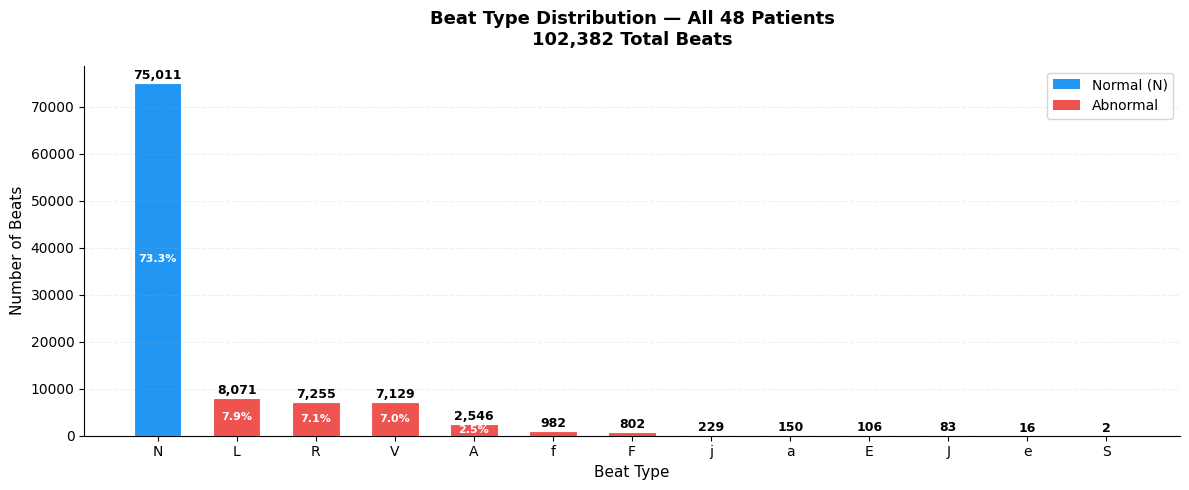

Beat type summary:
  N: 75,011 beats (73.3%)
  L: 8,071 beats (7.9%)
  R: 7,255 beats (7.1%)
  V: 7,129 beats (7.0%)
  A: 2,546 beats (2.5%)
  f: 982 beats (1.0%)
  F: 802 beats (0.8%)
  j: 229 beats (0.2%)
  a: 150 beats (0.1%)
  E: 106 beats (0.1%)
  J: 83 beats (0.1%)
  e: 16 beats (0.0%)
  S: 2 beats (0.0%)


In [10]:
label_counts = Counter(y)
symbols = [item[0] for item in sorted(label_counts.items(),
           key=lambda x: -x[1])]
counts = [item[1] for item in sorted(label_counts.items(),
          key=lambda x: -x[1])]

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2196F3' if s == 'N' else '#EF5350' for s in symbols]
bars = ax.bar(symbols, counts, color=colors,
              edgecolor='white', linewidth=0.8, width=0.6)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{count:,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add percentage labels inside each bar
for bar, count in zip(bars, counts):
    percentage = count / len(y) * 100
    if percentage > 1.5:  # only show if bar is tall enough
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() / 2,
                f'{percentage:.1f}%',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

ax.set_title('Beat Type Distribution — All 48 Patients\n102,382 Total Beats',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Beat Type', fontsize=11)
ax.set_ylabel('Number of Beats', fontsize=11)
ax.grid(True, alpha=0.2, linestyle='--', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Normal (N)'),
                   Patch(facecolor='#EF5350', label='Abnormal')]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

print("Beat type summary:")
for symbol, count in zip(symbols, counts):
    print(f"  {symbol}: {count:,} beats ({count/len(y)*100:.1f}%)")

### Observations from class distribution

The bar chart clearly shows the class imbalance across the dataset:

- Normal beats (N) dominate with 75,011 beats — 73.3% of the entire dataset
- The remaining 26.7% is spread across 12 different abnormal beat types
- L, R and V are the most common abnormal types with roughly 7,000-8,000 each
- Rare types like S (2 beats) and e (16 beats) have very few examples

This imbalance means the ML model in Phase 4 must use class_weight=balanced
to prevent it from being biased towards predicting everything as Normal.
Without this correction a naive model could achieve 73.3% accuracy by simply
always predicting Normal, which would be medically useless as it would miss
every single abnormal heartbeat.